In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import wave
import numpy as np

def find_wav_files(root_folder):
    wav_files = []
    for foldername, subfolders, filenames in os.walk(root_folder):
        for filename in filenames:
            if filename.lower().endswith('.wav'):
                wav_files.append(os.path.join(foldername, filename))
    return wav_files


In [ ]:
def extract_features(filepath):
    wav = wave.open(filepath, 'rb')
    n_channels = wav.getnchannels()
    framerate = wav.getframerate()
    n_frames = wav.getnframes()
    signal = wav.readframes(n_frames)
    wav.close()

    signal = np.frombuffer(signal, dtype=np.int16)

    if n_channels > 1:
        signal = signal[::n_channels]  # take one channel

    if len(signal) < framerate * 2:
        return None  # skip files < 2s

    # Normalize signal
    signal = signal / np.max(np.abs(signal))

    # Duration
    duration = len(signal) / framerate

    # FFT-based features
    spectrum = np.fft.fft(signal)
    magnitude = np.abs(spectrum[:len(spectrum)//2])
    freq = np.fft.fftfreq(len(signal), 1/framerate)[:len(spectrum)//2]

    mag_sum = np.sum(magnitude)
    if mag_sum == 0:
        return None
    norm_magnitude = magnitude / mag_sum

    # Spectral Centroid
    centroid = np.sum(freq * norm_magnitude)

    # Spectral Bandwidth
    bandwidth = np.sqrt(np.sum(((freq - centroid)**2) * norm_magnitude))

    # Spectral Rolloff (85%)
    cumulative_energy = np.cumsum(norm_magnitude)
    rolloff_idx = np.where(cumulative_energy >= 0.85)[0]
    rolloff_freq = freq[rolloff_idx[0]] if len(rolloff_idx) > 0 else freq[-1]

    # Zero Crossing Rate
    zero_crossings = np.sum(np.diff(np.sign(signal)) != 0) / len(signal)

    # Root Mean Square Energy
    rmse = np.sqrt(np.mean(signal**2))

    # Tempo estimate (count energy peaks in segments)
    window_size = framerate // 2  # half-second
    energy_peaks = 0
    for i in range(0, len(signal) - window_size, window_size):
        window = signal[i:i+window_size]
        energy = np.sqrt(np.mean(window**2))
        if energy > 0.1:
            energy_peaks += 1
    tempo_estimate = (energy_peaks * 60) / duration  # approx BPM

    return [centroid, bandwidth, rolloff_freq, zero_crossings, rmse, tempo_estimate, duration]

In [ ]:
def prepare_dataset(dataset_path):
    X = []
    y = []
    wav_files = find_wav_files(dataset_path)
    for file_path in wav_files:
        try:
            features = extract_features(file_path)
            if features is not None:
                label = os.path.basename(os.path.dirname(file_path))
                X.append(features)
                y.append(label)
        except Exception as e:
            print(f"Failed to process {file_path}: {e}")
    return X, y


In [ ]:
def normalize_features(X):
    X_np = np.array(X)
    min_vals = X_np.min(axis=0)
    max_vals = X_np.max(axis=0)
    norm_X = (X_np - min_vals) / (max_vals - min_vals + 1e-9)
    return norm_X.tolist()


In [ ]:
dataset_path = '/content/drive/MyDrive/genres_original'
X, y = prepare_dataset(dataset_path)
print("Dataset size:", len(X))

Dataset size: 999


> KNN

In [ ]:
def euclidean_distance(a, b):
    return np.sqrt(sum((x - y) ** 2 for x, y in zip(a, b)))

def knn_predict(X_train, y_train, x_test, k=3):
    distances = [(euclidean_distance(x_test, x_train), label) for x_train, label in zip(X_train, y_train)]
    distances.sort(key=lambda x: x[0])
    k_nearest = [label for _, label in distances[:k]]
    return max(set(k_nearest), key=k_nearest.count)


In [ ]:
def evaluate_knn(X, y, k=3):
    correct = 0
    total = len(X)
    for i in range(total):
        X_train = X[:i] + X[i+1:]
        y_train = y[:i] + y[i+1:]
        y_pred = knn_predict(X_train, y_train, X[i], k)
        if y_pred == y[i]:
            correct += 1
    return correct / total


In [ ]:

import random

k_values = list(range(1, 16))  # Create a list from 1 to 15
# test_k_value = random.shuffle(k_values)       # Shuffle the list in-place
k_values = k_values[:15]


best_k = None
best_acc = 0

for k in sorted(k_values):
    accuracy = evaluate_knn(X, y, k)
    print(f"k-NN Accuracy (k={k}): {accuracy * 100:.2f}%")
    if accuracy > best_acc:
        best_acc = accuracy
        best_k = k

print(f"\n✅ Best Accuracy: {best_acc * 100:.2f}% with k = {best_k}")

k-NN Accuracy (k=1): 31.33%
k-NN Accuracy (k=2): 27.03%
k-NN Accuracy (k=3): 31.63%
k-NN Accuracy (k=4): 32.83%
k-NN Accuracy (k=5): 34.43%
k-NN Accuracy (k=6): 35.04%
k-NN Accuracy (k=7): 35.04%
k-NN Accuracy (k=8): 33.53%
k-NN Accuracy (k=9): 31.43%
k-NN Accuracy (k=10): 32.03%
k-NN Accuracy (k=11): 32.03%
k-NN Accuracy (k=12): 32.73%
k-NN Accuracy (k=13): 32.83%
k-NN Accuracy (k=14): 33.73%
k-NN Accuracy (k=15): 33.93%

✅ Best Accuracy: 35.04% with k = 6


k-NN Accuracy (k=1): 31.33%
k-NN Accuracy (k=2): 27.73%
k-NN Accuracy (k=3): 31.13%
k-NN Accuracy (k=4): 32.03%
k-NN Accuracy (k=5): 35.34%
k-NN Accuracy (k=6): 35.14%
k-NN Accuracy (k=7): 34.53%
k-NN Accuracy (k=8): 32.93%
k-NN Accuracy (k=9): 31.53%
k-NN Accuracy (k=10): 32.93%
k-NN Accuracy (k=11): 32.73%
k-NN Accuracy (k=12): 32.73%
k-NN Accuracy (k=13): 33.53%
k-NN Accuracy (k=14): 33.93%
k-NN Accuracy (k=15): 33.63%


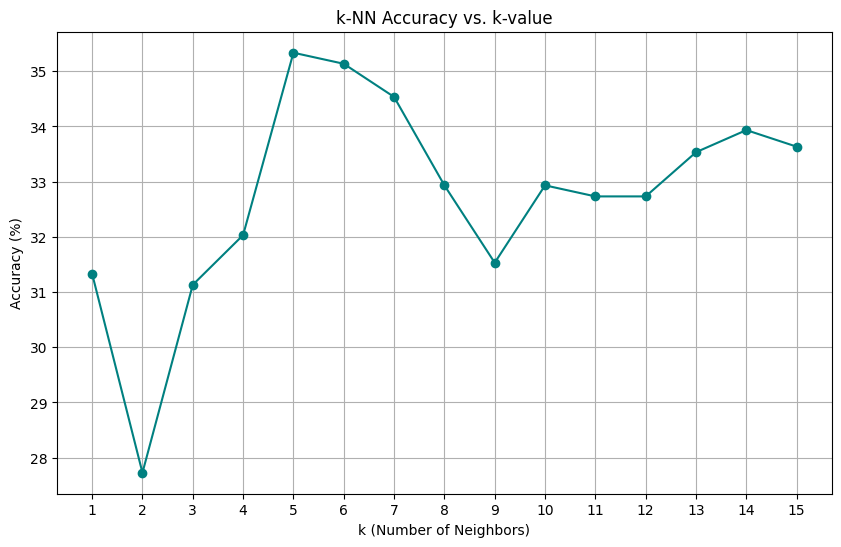

In [ ]:
import matplotlib.pyplot as plt


# Evaluate and store results
import random

k_values = list(range(1, 16))  # Create a list from 1 to 15
# random.shuffle(k_values)       # Shuffle the list in-place
k_values = k_values[:15]   # Take only the required number (up to 15) in case it overflows

accuracies = []

for k in k_values:
    acc = evaluate_knn(X, y, k)
    accuracies.append(acc)
    print(f"k-NN Accuracy (k={k}): {acc * 100:.2f}%")

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(k_values, [a * 100 for a in accuracies], marker='o', linestyle='-', color='teal')
plt.title('k-NN Accuracy vs. k-value')
plt.xlabel('k (Number of Neighbors)')
plt.ylabel('Accuracy (%)')
plt.xticks(k_values)
plt.grid(True)
plt.show()

k=1 | Acc=0.30 | Prec=0.30 | Rec=0.31 | F1=0.30
k=2 | Acc=0.30 | Prec=0.30 | Rec=0.31 | F1=0.30
k=3 | Acc=0.30 | Prec=0.29 | Rec=0.32 | F1=0.30
k=4 | Acc=0.32 | Prec=0.30 | Rec=0.34 | F1=0.31
k=5 | Acc=0.30 | Prec=0.27 | Rec=0.32 | F1=0.29
k=6 | Acc=0.30 | Prec=0.26 | Rec=0.33 | F1=0.28
k=7 | Acc=0.29 | Prec=0.27 | Rec=0.33 | F1=0.28
k=8 | Acc=0.29 | Prec=0.26 | Rec=0.33 | F1=0.27
k=9 | Acc=0.31 | Prec=0.29 | Rec=0.34 | F1=0.29
k=10 | Acc=0.32 | Prec=0.30 | Rec=0.35 | F1=0.30
k=11 | Acc=0.33 | Prec=0.31 | Rec=0.36 | F1=0.31
k=12 | Acc=0.33 | Prec=0.31 | Rec=0.36 | F1=0.31
k=13 | Acc=0.32 | Prec=0.31 | Rec=0.35 | F1=0.30
k=14 | Acc=0.32 | Prec=0.29 | Rec=0.36 | F1=0.30
k=15 | Acc=0.30 | Prec=0.26 | Rec=0.33 | F1=0.27

✅ Best Accuracy: 33.17% with k = 11


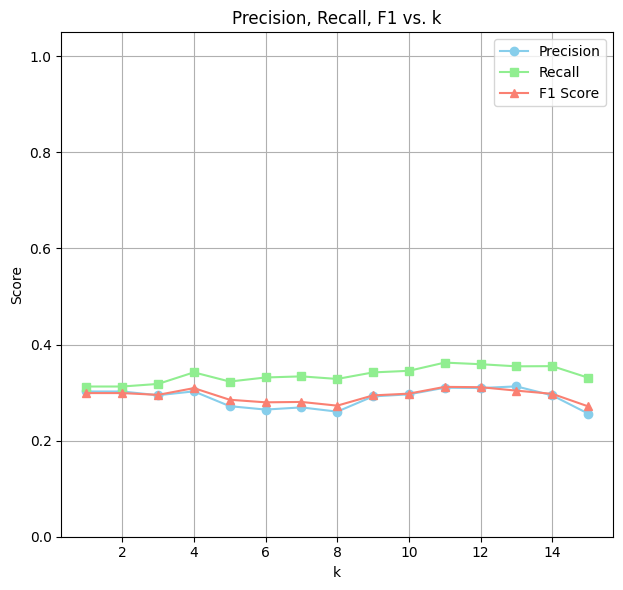

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

k_values = list(range(1, 16))
acc_list = []
prec_list = []
rec_list = []
f1_list = []

best_k = None
best_acc = 0

# Manual split (used for all k)
X = np.array(X)
y = np.array(y)
np.random.seed(42)
indices = np.arange(len(X))
np.random.shuffle(indices)
split = int(len(X) * 0.2)
test_idx = indices[:split]
train_idx = indices[split:]
X_train, y_train = X[train_idx], y[train_idx]
X_test, y_test = X[test_idx], y[test_idx]

# Label mapping for string to integer conversion
label_to_int = {label: idx for idx, label in enumerate(np.unique(y))}

def compute_metrics(y_true, y_pred, num_classes):
    cm = np.zeros((num_classes, num_classes), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[t][p] += 1

    precision, recall, f1 = [], [], []
    for i in range(num_classes):
        TP = cm[i][i]
        FP = np.sum(cm[:, i]) - TP
        FN = np.sum(cm[i, :]) - TP
        prec = TP / (TP + FP + 1e-9)
        rec = TP / (TP + FN + 1e-9)
        f1_score = 2 * prec * rec / (prec + rec + 1e-9)
        precision.append(prec)
        recall.append(rec)
        f1.append(f1_score)

    return np.mean(precision), np.mean(recall), np.mean(f1)

for k in k_values:
    y_pred = []

    for test_point in X_test:
        distances = np.linalg.norm(X_train - test_point, axis=1)
        nn_indices = np.argsort(distances)[:k]
        nn_labels = y_train[nn_indices]
        most_common = Counter(nn_labels).most_common(1)[0][0]
        y_pred.append(most_common)

    y_pred = np.array(y_pred)

    # Convert string labels to integer IDs for indexing
    y_test_int = np.array([label_to_int[label] if isinstance(label, str) else label for label in y_test])
    y_pred_int = np.array([label_to_int[label] if isinstance(label, str) else label for label in y_pred])

    # Calculate metrics
    acc = np.mean(y_pred_int == y_test_int)
    acc_list.append(acc)

    # Compute Precision, Recall, F1
    prec, rec, f1 = compute_metrics(y_test_int, y_pred_int, num_classes=len(np.unique(y)))
    prec_list.append(prec)
    rec_list.append(rec)
    f1_list.append(f1)

    print(f"k={k} | Acc={acc:.2f} | Prec={prec:.2f} | Rec={rec:.2f} | F1={f1:.2f}")

    if acc > best_acc:
        best_acc = acc
        best_k = k

print(f"\n✅ Best Accuracy: {best_acc * 100:.2f}% with k = {best_k}")

# ---- PLOTS ----

plt.figure(figsize=(12, 6))


# Precision, Recall, F1 vs. k
plt.subplot(1, 2, 2)
plt.plot(k_values, prec_list, marker='o', label='Precision', color='skyblue')
plt.plot(k_values, rec_list, marker='s', label='Recall', color='lightgreen')
plt.plot(k_values, f1_list, marker='^', label='F1 Score', color='salmon')
plt.title("Precision, Recall, F1 vs. k")
plt.xlabel("k")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


> DECISION TREE

In [ ]:
def gini_impurity(labels):
    total = len(labels)
    if total == 0:
        return 0
    counts = {}
    for label in labels:
        counts[label] = counts.get(label, 0) + 1
    impurity = 1.0
    for label in counts:
        prob = counts[label] / total
        impurity -= prob ** 2
    return impurity


In [ ]:
def best_split(X, y):
    best_gain = 0
    best_index = None
    best_value = None
    current_impurity = gini_impurity(y)

    for feature_index in range(len(X[0])):
        values = set(row[feature_index] for row in X)
        for val in values:
            left_X, right_X, left_y, right_y = [], [], [], []
            for i in range(len(X)):
                if X[i][feature_index] <= val:
                    left_X.append(X[i])
                    left_y.append(y[i])
                else:
                    right_X.append(X[i])
                    right_y.append(y[i])
            if len(left_y) == 0 or len(right_y) == 0:
                continue
            p = len(left_y) / len(y)
            gain = current_impurity - (p * gini_impurity(left_y) + (1 - p) * gini_impurity(right_y))
            if gain > best_gain:
                best_gain = gain
                best_index = feature_index
                best_value = val
    return best_index, best_value


In [ ]:
class TreeNode:
    def __init__(self, feature_index=None, value=None, left=None, right=None, prediction=None):
        self.feature_index = feature_index
        self.value = value
        self.left = left
        self.right = right
        self.prediction = prediction

def build_tree(X, y, depth=0, max_depth=10, min_size=1):
    if len(set(y)) == 1 or depth >= max_depth or len(X) <= min_size:
        # Leaf node
        prediction = max(set(y), key=y.count)
        return TreeNode(prediction=prediction)

    index, value = best_split(X, y)
    if index is None:
        return TreeNode(prediction=max(set(y), key=y.count))

    left_X, right_X, left_y, right_y = [], [], [], []
    for i in range(len(X)):
        if X[i][index] <= value:
            left_X.append(X[i])
            left_y.append(y[i])
        else:
            right_X.append(X[i])
            right_y.append(y[i])

    left_node = build_tree(left_X, left_y, depth+1, max_depth, min_size)
    right_node = build_tree(right_X, right_y, depth+1, max_depth, min_size)
    return TreeNode(index, value, left_node, right_node)


In [ ]:
def tree_predict(node, row):
    if node.prediction is not None:
        return node.prediction
    if row[node.feature_index] <= node.value:
        return tree_predict(node.left, row)
    else:
        return tree_predict(node.right, row)


In [ ]:

def evaluate_tree(X, y, max_depth=10):
    correct = 0
    total = len(X)
    for i in range(total):
        X_train = X[:i] + X[i+1:]
        y_train = y[:i] + y[i+1:]
        tree = build_tree(X_train, y_train, max_depth=max_depth)
        y_pred = tree_predict(tree, X[i])
        if y_pred == y[i]:
            correct += 1
    return correct / total


# X = normalize_features(X)
accuracy = evaluate_tree(X, y, max_depth=5)
print(f"Decision Tree Accuracy: {accuracy * 100:.2f}%")


> SVM

In [ ]:
import numpy as np
from random import shuffle
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

def one_vs_all_labels(y, target_class):
    return np.array([1 if label == target_class else -1 for label in y])

class SimpleLinearSVM:
    def __init__(self, learning_rate=0.001, lambda_param=0.01, n_iters=1000):
        self.lr = learning_rate
        self.lambda_param = lambda_param
        self.n_iters = n_iters
        self.w = None
        self.b = None

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0

        for _ in range(self.n_iters):
            for idx, x_i in enumerate(X):
                condition = y[idx] * (np.dot(x_i, self.w) - self.b) >= 1
                if condition:
                    self.w -= self.lr * (2 * self.lambda_param * self.w)
                else:
                    self.w -= self.lr * (2 * self.lambda_param * self.w - np.dot(x_i, y[idx]))
                    self.b -= self.lr * y[idx]

    def predict(self, X):
        approx = np.dot(X, self.w) - self.b
        return np.sign(approx)

def normalize_features(X):
    X = np.array(X)
    min_vals = X.min(axis=0)
    max_vals = X.max(axis=0)
    return (X - min_vals) / (max_vals - min_vals + 1e-8)

def evaluate_manual_svm(X, y, lam=0.01):
    # Normalize features
    X = normalize_features(X)
    X = np.array(X)
    y = np.array(y)

    # Get unique classes for one-vs-rest
    classes = np.unique(y)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Train one-vs-rest classifiers
    classifiers = {}
    for cls in classes:
        binary_y = one_vs_all_labels(y_train, cls)
        svm = SimpleLinearSVM(lambda_param=lam)
        svm.fit(X_train, binary_y)
        classifiers[cls] = svm

    # Predict
    predictions = []
    for x in X_test:
        scores = {cls: np.dot(x, clf.w) - clf.b for cls, clf in classifiers.items()}
        pred = max(scores, key=scores.get)
        predictions.append(pred)

    # Accuracy
    acc = np.mean(np.array(predictions) == y_test)
    print(f"Lambda {lam}: Manual Linear SVM Accuracy = {acc * 100:.2f}%")
    return acc


In [ ]:
# X, y = prepare_dataset("/content/drive/MyDrive/genres_original")  #<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<
evaluate_manual_svm(X, y,lam=0.01)


Lambda 0.01: Manual Linear SVM Accuracy = 30.50%


np.float64(0.305)

Lambda 0.001: Manual Linear SVM Accuracy = 29.50%
Lambda 0.001: Accuracy = 29.50%
Lambda 0.002: Manual Linear SVM Accuracy = 33.50%
Lambda 0.002: Accuracy = 33.50%
Lambda 0.003: Manual Linear SVM Accuracy = 29.50%
Lambda 0.003: Accuracy = 29.50%
Lambda 0.004: Manual Linear SVM Accuracy = 29.50%
Lambda 0.004: Accuracy = 29.50%
Lambda 0.006: Manual Linear SVM Accuracy = 29.50%
Lambda 0.006: Accuracy = 29.50%
Lambda 0.009: Manual Linear SVM Accuracy = 30.50%
Lambda 0.009: Accuracy = 30.50%
Lambda 0.013: Manual Linear SVM Accuracy = 27.50%
Lambda 0.013: Accuracy = 27.50%
Lambda 0.018: Manual Linear SVM Accuracy = 29.00%
Lambda 0.018: Accuracy = 29.00%
Lambda 0.026: Manual Linear SVM Accuracy = 29.00%
Lambda 0.026: Accuracy = 29.00%
Lambda 0.038: Manual Linear SVM Accuracy = 26.50%
Lambda 0.038: Accuracy = 26.50%
Lambda 0.055: Manual Linear SVM Accuracy = 28.00%
Lambda 0.055: Accuracy = 28.00%
Lambda 0.078: Manual Linear SVM Accuracy = 26.50%
Lambda 0.078: Accuracy = 26.50%
Lambda 0.113: Ma

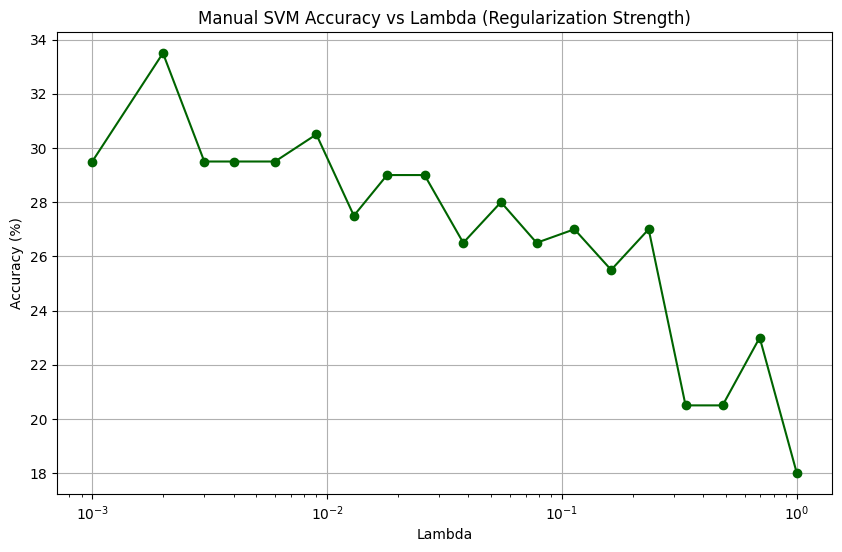

In [ ]:
lambda_values = np.unique(np.round(np.logspace(-3, 0, num=20), 3))

accuracies = []

for lam in lambda_values:
    svm_acc = evaluate_manual_svm(X, y, lam)  # You'd need to modify your function to take lambda_param
    accuracies.append(svm_acc)
    print(f"Lambda {lam}: Accuracy = {svm_acc * 100:.2f}%")

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(lambda_values, [a * 100 for a in accuracies], marker='o', linestyle='-', color='darkgreen')
plt.title('Manual SVM Accuracy vs Lambda (Regularization Strength)')
plt.xlabel('Lambda')
plt.ylabel('Accuracy (%)')
plt.xscale('log')  # Optional: log scale for lambda
plt.grid(True)
plt.show()

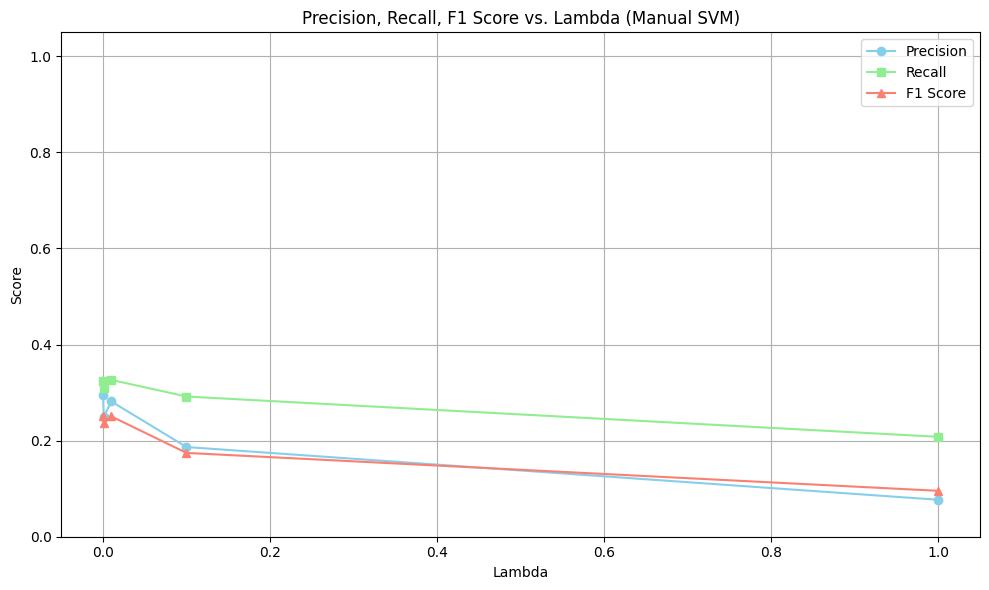

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def compute_manual_metrics(y_true, y_pred, classes):
    num_classes = len(classes)
    cm = np.zeros((num_classes, num_classes), dtype=int)
    class_to_idx = {cls: idx for idx, cls in enumerate(classes)}

    for t, p in zip(y_true, y_pred):
        cm[class_to_idx[t]][class_to_idx[p]] += 1

    precision, recall, f1 = [], [], []
    for i in range(num_classes):
        TP = cm[i][i]
        FP = np.sum(cm[:, i]) - TP
        FN = np.sum(cm[i, :]) - TP

        prec = TP / (TP + FP + 1e-9)
        rec = TP / (TP + FN + 1e-9)
        f1_score = 2 * prec * rec / (prec + rec + 1e-9)

        precision.append(prec)
        recall.append(rec)
        f1.append(f1_score)

    return np.mean(precision), np.mean(recall), np.mean(f1)

# Vary lambda and collect metrics
lambda_values = [0.0001, 0.001, 0.01, 0.1, 1]
prec_list, rec_list, f1_list = [], [], []

for lam in lambda_values:
    # Normalize and split again
    X_norm = normalize_features(X)
    X_train, X_test, y_train, y_test = train_test_split(X_norm, y, test_size=0.2, random_state=42)

    classes = np.unique(y)
    classifiers = {}
    for cls in classes:
        binary_y = one_vs_all_labels(y_train, cls)
        svm = SimpleLinearSVM(lambda_param=lam)
        svm.fit(X_train, binary_y)
        classifiers[cls] = svm

    y_pred = []
    for x in X_test:
        scores = {cls: np.dot(x, clf.w) - clf.b for cls, clf in classifiers.items()}
        pred = max(scores, key=scores.get)
        y_pred.append(pred)

    prec, rec, f1 = compute_manual_metrics(y_test, y_pred, classes)
    prec_list.append(prec)
    rec_list.append(rec)
    f1_list.append(f1)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(lambda_values, prec_list, label='Precision', marker='o', color='skyblue')
plt.plot(lambda_values, rec_list, label='Recall', marker='s', color='lightgreen')
plt.plot(lambda_values, f1_list, label='F1 Score', marker='^', color='salmon')
plt.title("Precision, Recall, F1 Score vs. Lambda (Manual SVM)")
plt.xlabel("Lambda")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


> Naive Bayes

In [ ]:

import numpy as np


import random

def my_train_test_split(X, y, test_size=0.2, random_state=None):
    """Splits data into random train and test subsets.

    Args:
        X: The feature data (list or numpy array).
        y: The target labels (list or numpy array).
        test_size: Proportion of the dataset to include in the test split (default 0.2).
        random_state: Controls the shuffling applied to the data before applying the split (default None).

    Returns:
        X_train, X_test, y_train, y_test: The split data.
    """

    if random_state is not None:
        random.seed(random_state)  # Set random seed for reproducibility

    dataset = list(zip(X, y))  # Combine features and labels
    random.shuffle(dataset)  # Shuffle the dataset

    split_index = int(len(dataset) * (1 - test_size))  # Calculate split index
    X_train, y_train = zip(*dataset[:split_index])  # Extract training data
    X_test, y_test = zip(*dataset[split_index:])  # Extract testing data

    return list(X_train), list(X_test), list(y_train), list(y_test)  # Convert back to lists

class GaussianNaiveBayes:
    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y)
        self.classes = np.unique(y)
        self.mean = {}
        self.var = {}
        self.priors = {}

        for cls in self.classes:
            X_c = X[y == cls]
            self.mean[cls] = np.mean(X_c, axis=0)
            self.var[cls] = np.var(X_c, axis=0) + 1e-9  # prevent division by zero
            self.priors[cls] = X_c.shape[0] / X.shape[0]

    def gaussian_prob(self, class_idx, x):
        mean = self.mean[class_idx]
        var = self.var[class_idx]
        numerator = np.exp(-((x - mean) ** 2) / (2 * var))
        denominator = np.sqrt(2 * np.pi * var)
        return numerator / denominator

    def predict(self, X):
        X = np.array(X)
        predictions = []
        for x in X:
            posteriors = []
            for cls in self.classes:
                prior = np.log(self.priors[cls])
                class_likelihood = np.sum(np.log(self.gaussian_prob(cls, x)))
                posterior = prior + class_likelihood
                posteriors.append(posterior)
            predictions.append(self.classes[np.argmax(posteriors)])
        return predictions

def evaluate_naive_bayes(X, y):
    X = normalize_features(X)  # use your min-max function
    X = np.array(X)
    y = np.array(y)

    # Split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Train & Predict
    model = GaussianNaiveBayes()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Accuracy
    acc = np.mean(y_pred == y_test)
    print(f"Naive Bayes Accuracy: {acc * 100:.2f}%")



In [ ]:
# X, y = prepare_dataset("/content/drive/MyDrive/genres_original")  #<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<,
evaluate_naive_bayes(X, y)

Naive Bayes Accuracy: 30.00%


<ipython-input-36-02eb67724076>:60: RuntimeWarning: divide by zero encountered in log
  class_likelihood = np.sum(np.log(self.gaussian_prob(cls, x)))


<ipython-input-20-02eb67724076>:60: RuntimeWarning: divide by zero encountered in log
  class_likelihood = np.sum(np.log(self.gaussian_prob(cls, x)))


Run 1: Accuracy = 24.00%
Run 2: Accuracy = 29.00%
Run 3: Accuracy = 25.50%
Run 4: Accuracy = 25.50%
Run 5: Accuracy = 25.00%
Run 6: Accuracy = 25.50%
Run 7: Accuracy = 26.50%
Run 8: Accuracy = 22.00%
Run 9: Accuracy = 26.00%
Run 10: Accuracy = 26.00%
Run 11: Accuracy = 25.50%
Run 12: Accuracy = 22.00%
Run 13: Accuracy = 24.00%
Run 14: Accuracy = 26.00%
Run 15: Accuracy = 24.00%
Run 16: Accuracy = 28.50%
Run 17: Accuracy = 23.50%
Run 18: Accuracy = 24.50%
Run 19: Accuracy = 24.50%
Run 20: Accuracy = 30.50%
Run 21: Accuracy = 17.00%
Run 22: Accuracy = 20.50%
Run 23: Accuracy = 30.50%
Run 24: Accuracy = 28.00%
Run 25: Accuracy = 24.50%
Run 26: Accuracy = 20.50%
Run 27: Accuracy = 27.00%
Run 28: Accuracy = 24.00%
Run 29: Accuracy = 27.00%
Run 30: Accuracy = 24.50%
Run 31: Accuracy = 26.00%
Run 32: Accuracy = 26.00%
Run 33: Accuracy = 29.50%
Run 34: Accuracy = 24.00%
Run 35: Accuracy = 29.00%
Run 36: Accuracy = 25.00%
Run 37: Accuracy = 32.00%
Run 38: Accuracy = 24.00%
Run 39: Accuracy = 26

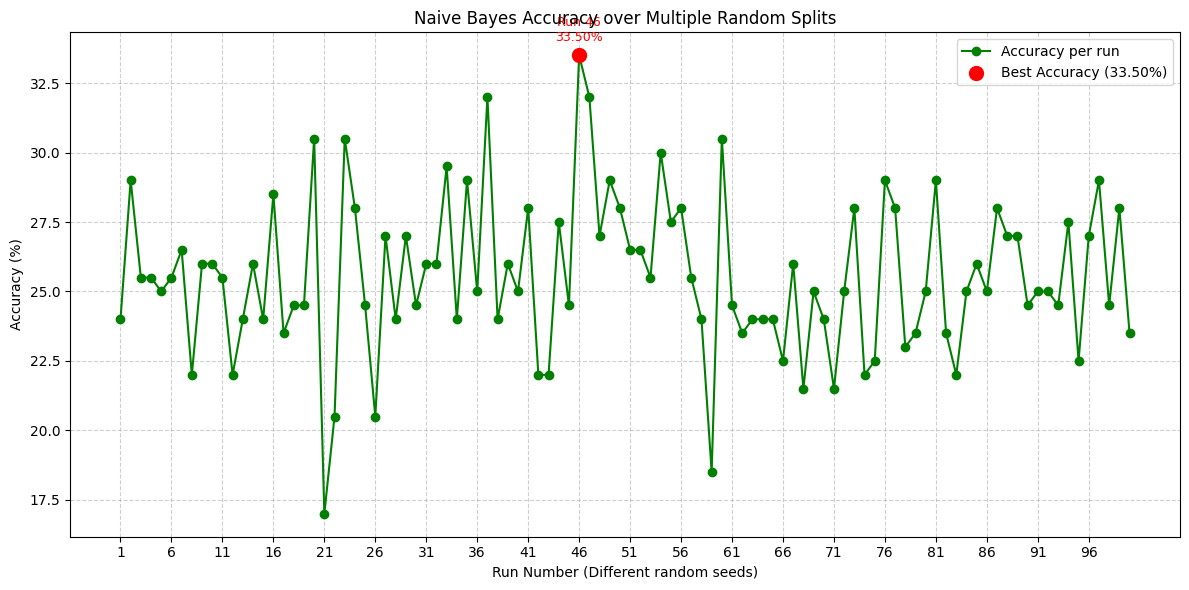


✅ Best Accuracy: 33.50% on Run 46


In [ ]:
import matplotlib.pyplot as plt

split_runs = 100
accuracies = []

for seed in range(split_runs):
    X_train, X_test, y_train, y_test = my_train_test_split(X, y, test_size=0.2, random_state=seed)

    # Normalize only train and test independently if you want a fair split
    X_train = normalize_features(X_train)
    X_test = normalize_features(X_test)

    model = GaussianNaiveBayes()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = np.mean(np.array(y_pred) == np.array(y_test))
    accuracies.append(acc)
    print(f"Run {seed + 1}: Accuracy = {acc * 100:.2f}%")

# Best run info
best_run_idx = np.argmax(accuracies)
best_run = best_run_idx + 1
best_accuracy = accuracies[best_run_idx] * 100

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(range(1, split_runs + 1), [a * 100 for a in accuracies], marker='o', linestyle='-', color='green', label='Accuracy per run')
plt.scatter(best_run, best_accuracy, color='red', s=100, zorder=5, label=f'Best Accuracy ({best_accuracy:.2f}%)')
plt.text(best_run, best_accuracy + 0.5, f"Run {best_run}\n{best_accuracy:.2f}%", ha='center', fontsize=9, color='red')

plt.title('Naive Bayes Accuracy over Multiple Random Splits')
plt.xlabel('Run Number (Different random seeds)')
plt.ylabel('Accuracy (%)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(range(1, split_runs + 1, max(1, split_runs // 20)))
plt.legend()
plt.tight_layout()
plt.show()

print(f"\n✅ Best Accuracy: {best_accuracy:.2f}% on Run {best_run}")


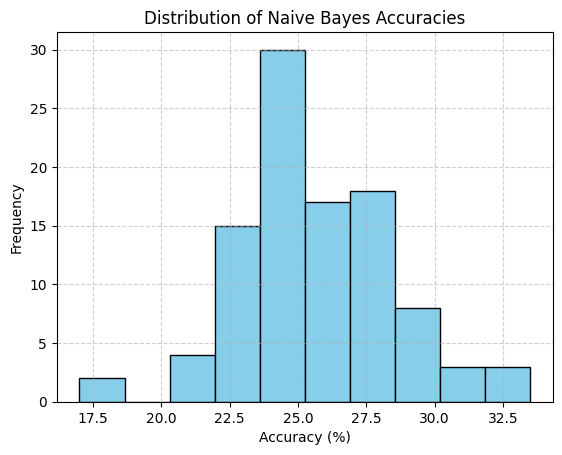

In [ ]:
plt.hist([a * 100 for a in accuracies], bins=10, color='skyblue', edgecolor='black')
plt.title("Distribution of Naive Bayes Accuracies")
plt.xlabel("Accuracy (%)")
plt.ylabel("Frequency")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


<ipython-input-36-02eb67724076>:60: RuntimeWarning: divide by zero encountered in log
  class_likelihood = np.sum(np.log(self.gaussian_prob(cls, x)))


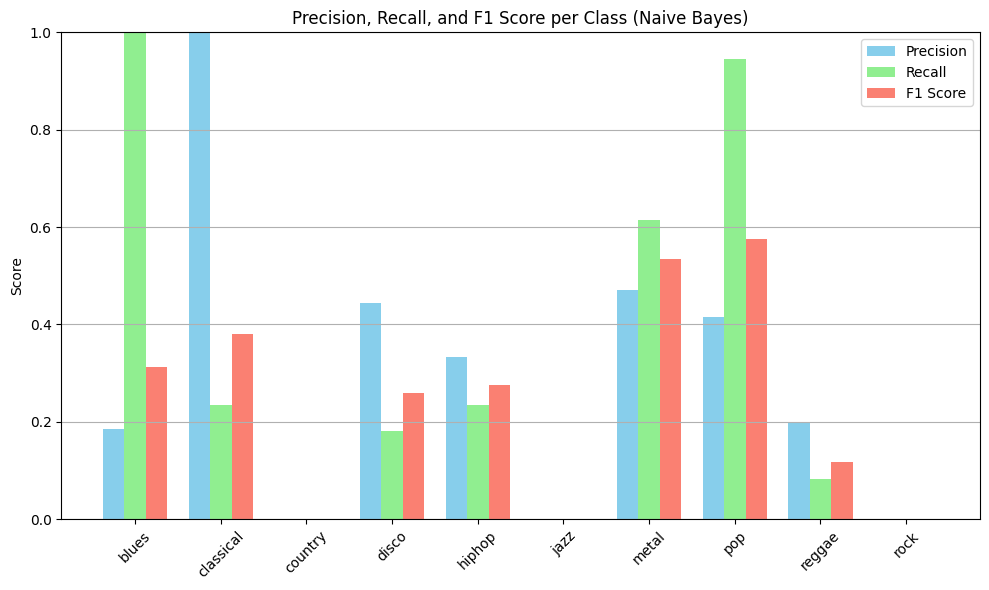

In [ ]:
import matplotlib.pyplot as plt

def compute_manual_metrics(y_true, y_pred, classes):
    num_classes = len(classes)
    cm = np.zeros((num_classes, num_classes), dtype=int)
    class_to_idx = {cls: idx for idx, cls in enumerate(classes)}

    for t, p in zip(y_true, y_pred):
        cm[class_to_idx[t]][class_to_idx[p]] += 1

    precision, recall, f1 = [], [], []
    for i in range(num_classes):
        TP = cm[i][i]
        FP = np.sum(cm[:, i]) - TP
        FN = np.sum(cm[i, :]) - TP

        prec = TP / (TP + FP + 1e-9)
        rec = TP / (TP + FN + 1e-9)
        f1_score = 2 * prec * rec / (prec + rec + 1e-9)

        precision.append(prec)
        recall.append(rec)
        f1.append(f1_score)

    return precision, recall, f1, classes

# Re-run evaluation with predictions captured
X_norm = normalize_features(X)
X_train, X_test, y_train, y_test = my_train_test_split(X_norm, y, test_size=0.2, random_state=42)

model = GaussianNaiveBayes()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Compute metrics
precision, recall, f1, class_labels = compute_manual_metrics(y_test, y_pred, np.unique(y))

# Plot
x = np.arange(len(class_labels))
width = 0.25

plt.figure(figsize=(10, 6))
plt.bar(x - width, precision, width, label='Precision', color='skyblue')
plt.bar(x, recall, width, label='Recall', color='lightgreen')
plt.bar(x + width, f1, width, label='F1 Score', color='salmon')
plt.xticks(x, [str(c) for c in class_labels], rotation=45)
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Precision, Recall, and F1 Score per Class (Naive Bayes)")
plt.legend()
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()


> K-Means Clustering

In [ ]:
import numpy as np

class KMeansClustering:
    def __init__(self, k=10, max_iters=100):
        self.k = k
        self.max_iters = max_iters
        self.centroids = []
        self.labels = []

    def initialize_centroids(self, X):
        indices = np.arange(len(X))
        np.random.shuffle(indices)
        centroids = [X[i] for i in indices[:self.k]]
        return centroids

    def assign_clusters(self, X, centroids):
        clusters = [[] for _ in range(self.k)]
        for x in X:
            distances = [np.linalg.norm(np.array(x) - np.array(c)) for c in centroids]
            cluster_idx = np.argmin(distances)
            clusters[cluster_idx].append(x)
        return clusters

    def update_centroids(self, clusters):
        new_centroids = []
        for cluster in clusters:
            if len(cluster) > 0:
                new_centroids.append(np.mean(cluster, axis=0).tolist())
            else:
                new_centroids.append([0.0] * len(clusters[0][0]))  # handle empty cluster
        return new_centroids

    def fit(self, X):
        X = np.array(X)
        self.centroids = self.initialize_centroids(X)
        for _ in range(self.max_iters):
            clusters = self.assign_clusters(X, self.centroids)
            new_centroids = self.update_centroids(clusters)
            if np.allclose(self.centroids, new_centroids):
                break
            self.centroids = new_centroids

        self.labels = []
        for x in X:
            distances = [np.linalg.norm(np.array(x) - np.array(c)) for c in self.centroids]
            cluster_idx = np.argmin(distances)
            self.labels.append(cluster_idx)


In [ ]:
def evaluate_kmeans(X, y, k=10):
    X = normalize_features(X)
    X = np.array(X)
    y = np.array(y)

    kmeans = KMeansClustering(k=k)
    kmeans.fit(X)
    predicted_clusters = kmeans.labels

    # Manual mapping from cluster -> most frequent label
    cluster_to_labels = {}
    for i in range(k):
        cluster_to_labels[i] = []

    for cluster, label in zip(predicted_clusters, y):
        cluster_to_labels[cluster].append(label)

    cluster_label_map = {}
    for cluster in cluster_to_labels:
        label_counts = {}
        for label in cluster_to_labels[cluster]:
            if label not in label_counts:
                label_counts[label] = 0
            label_counts[label] += 1
        # Get most common label manually
        most_common_label = None
        max_count = -1
        for label, count in label_counts.items():
            if count > max_count:
                max_count = count
                most_common_label = label
        cluster_label_map[cluster] = most_common_label

    # Predict final labels using cluster map
    predicted_labels = [cluster_label_map[c] for c in predicted_clusters]

    acc = np.mean(predicted_labels == y)
    print(f"K-Means Accuracy (Manual): {acc * 100:.2f}%")


In [ ]:
# X, y = prepare_dataset("/content/drive/MyDrive/genres_original") #<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<
evaluate_kmeans(X, y, k=10)


K-Means Accuracy (Manual): 36.44%


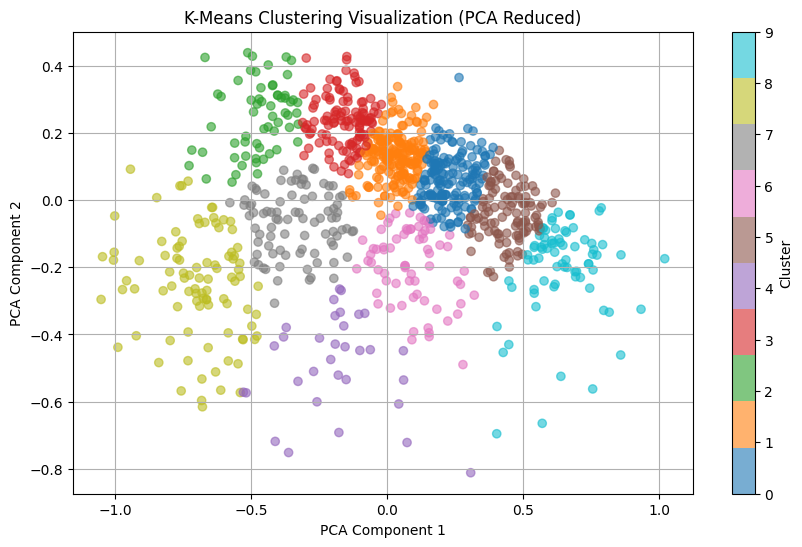

In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Reduce dimensionality for visualization
pca = PCA(n_components=2)
X_reduced = pca.fit_transform(normalize_features(X))  # Normalizing again to match k-means input

# Fit KMeans again (since predicted_clusters, etc. are not stored across cells)
k = 10  # Define k here, set to 10 as it was in your previous evaluate_kmeans call
kmeans = KMeansClustering(k=k)
kmeans.fit(X_reduced)
predicted_clusters = kmeans.labels

# Plot
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=predicted_clusters, cmap='tab10', alpha=0.6)
plt.title('K-Means Clustering Visualization (PCA Reduced)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(scatter, label='Cluster')
plt.grid(True)
plt.show()

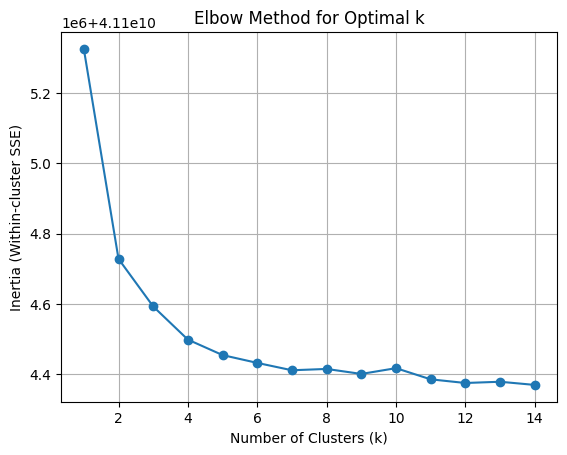

In [ ]:
inertias = []
K_range = range(1, 15)
for k in K_range:
    kmeans = KMeansClustering(k=k)
    kmeans.fit(normalize_features(X))

    # Inertia = sum of squared distances from each point to its cluster centroid
    inertia = 0
    for i, x in enumerate(X):
        centroid = kmeans.centroids[kmeans.labels[i]]
        inertia += np.sum((np.array(x) - np.array(centroid)) ** 2)

    inertias.append(inertia)

plt.plot(K_range, inertias, marker='o')
plt.title("Elbow Method for Optimal k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia (Within-cluster SSE)")
plt.grid(True)
plt.show()


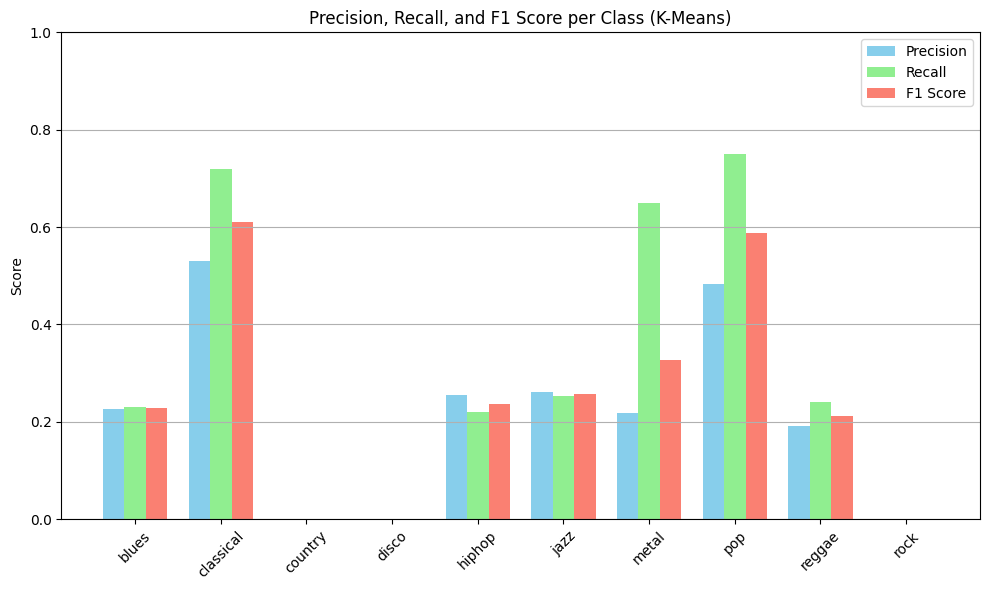

In [ ]:
import matplotlib.pyplot as plt

def compute_kmeans_metrics(y_true, y_pred, classes):
    num_classes = len(classes)
    cm = np.zeros((num_classes, num_classes), dtype=int)
    class_to_idx = {cls: idx for idx, cls in enumerate(classes)}

    for t, p in zip(y_true, y_pred):
        cm[class_to_idx[t]][class_to_idx[p]] += 1

    precision, recall, f1 = [], [], []
    for i in range(num_classes):
        TP = cm[i][i]
        FP = np.sum(cm[:, i]) - TP
        FN = np.sum(cm[i, :]) - TP

        prec = TP / (TP + FP + 1e-9)
        rec = TP / (TP + FN + 1e-9)
        f1_score = 2 * prec * rec / (prec + rec + 1e-9)

        precision.append(prec)
        recall.append(rec)
        f1.append(f1_score)

    return precision, recall, f1, classes

# Run K-Means and get predicted labels
X_norm = normalize_features(X)
X_arr = np.array(X)
y_arr = np.array(y)

kmeans = KMeansClustering(k=10)
kmeans.fit(X_arr)

# Map clusters to labels
cluster_to_labels = {i: [] for i in range(10)}
for cluster, label in zip(kmeans.labels, y_arr):
    cluster_to_labels[cluster].append(label)

cluster_label_map = {}
for cluster, labels in cluster_to_labels.items():
    label_counts = {}
    for label in labels:
        label_counts[label] = label_counts.get(label, 0) + 1
    cluster_label_map[cluster] = max(label_counts, key=label_counts.get, default=-1)

y_pred = [cluster_label_map[c] for c in kmeans.labels]

# Metrics and plot
precision, recall, f1, class_labels = compute_kmeans_metrics(y_arr, y_pred, np.unique(y))

x = np.arange(len(class_labels))
width = 0.25

plt.figure(figsize=(10, 6))
plt.bar(x - width, precision, width, label='Precision', color='skyblue')
plt.bar(x, recall, width, label='Recall', color='lightgreen')
plt.bar(x + width, f1, width, label='F1 Score', color='salmon')
plt.xticks(x, [str(cls) for cls in class_labels], rotation=45)
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Precision, Recall, and F1 Score per Class (K-Means)")
plt.legend()
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()


> logistic regression

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# -----------------------------
# Multi-class Logistic Regression Code
# -----------------------------
def softmax(z):
    """
    Compute softmax values for each set of scores in z.
    z: ndarray of shape (m, num_classes)
    Returns:
       probabilities: ndarray of same shape as z
    """
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))  # for numerical stability
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)


class MultiClassLogisticRegression:
    def __init__(self, learning_rate=0.1, num_iterations=1000):
        """
        Multi-class logistic regression classifier using softmax.

        Parameters:
            learning_rate (float): Step size for gradient descent.
            num_iterations (int): Number of iterations for training.
        """
        self.learning_rate = learning_rate
        self.num_iterations = num_iterations

    def fit(self, X, y):
        """
        Train the logistic regression classifier.

        Parameters:
            X (ndarray): Input features of shape (m, n).
            y (ndarray): Integer labels of shape (m,), values 0,...,K-1.
        """
        m, n = X.shape
        self.num_classes = np.max(y) + 1
        # Initialize weights and biases
        self.weights = np.zeros((n, self.num_classes))
        self.bias = np.zeros((1, self.num_classes))

        # Convert y to one-hot encoding
        y_one_hot = np.eye(self.num_classes)[y]  # shape (m, num_classes)

        for i in range(self.num_iterations):
            # Linear scores: shape (m, num_classes)
            z = np.dot(X, self.weights) + self.bias
            # Predicted probabilities via softmax
            probs = softmax(z)  # shape (m, num_classes)

            # Compute the gradient of loss (cross entropy)
            dz = (probs - y_one_hot)  # shape (m, num_classes)
            dw = (1 / m) * np.dot(X.T, dz)  # shape (n, num_classes)
            db = (1 / m) * np.sum(dz, axis=0, keepdims=True)  # shape (1, num_classes)

            # Update parameters
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

    def predict(self, X):
        """
        Predict class labels for samples in X.

        Parameters:
            X (ndarray): Feature matrix of shape (m, n).

        Returns:
            predictions (ndarray): Predicted class labels of shape (m,).
        """
        z = np.dot(X, self.weights) + self.bias
        probs = softmax(z)
        return np.argmax(probs, axis=1)


def calculate_accuracy(y_true, y_pred):
    """Calculate accuracy as the fraction of correct predictions."""
    return np.mean(y_true == y_pred)


def custom_train_test_split(X, y, test_size=0.2, random_state=42):
    """
    Split arrays into random train and test subsets.

    Parameters:
        X (ndarray): Feature matrix.
        y (ndarray): Label array.
        test_size (float): Proportion to use as test data.
        random_state (int): Random seed.

    Returns:
        X_train, X_test, y_train, y_test: The split datasets.
    """
    if random_state is not None:
        np.random.seed(random_state)
    indices = np.arange(len(X))
    np.random.shuffle(indices)
    split = int(len(X) * test_size)
    test_indices = indices[:split]
    train_indices = indices[split:]
    return X[train_indices], X[test_indices], y[train_indices], y[test_indices]


# -----------------------------
# Main Code: Using Feature Extraction and Multi-class Logistic Regression
# -----------------------------
if __name__ == '__main__':
    # (Assuming you have already mounted your drive and run your feature extraction code)
    dataset_path = '/content/drive/MyDrive/genres_original'
    # X, y = prepare_dataset(dataset_path)
    print("Dataset size:", len(X))

    # Normalize features using your provided function
    X_norm = np.array(normalize_features(X))

    # Encode string labels to integers (mapping each genre to a unique integer)
    classes = np.unique(y)
    print("Classes:", classes)
    label_to_int = {label: idx for idx, label in enumerate(classes)}
    y_encoded = np.array([label_to_int[label] for label in y])

    # Split dataset into training and test sets
    X_train, X_test, y_train, y_test = custom_train_test_split(X_norm, y_encoded, test_size=0.2, random_state=42)

    # Train multi-class logistic regression
    model = MultiClassLogisticRegression(learning_rate=0.1, num_iterations=1000)
    model.fit(X_train, y_train)

    # Predict on the test set
    y_pred = model.predict(X_test)

    # Calculate and print accuracy
    acc = calculate_accuracy(y_test, y_pred)
    print(f"Multi-class Logistic Regression Accuracy: {acc * 100:.2f}%")



Dataset size: 999
Classes: ['blues' 'classical' 'country' 'disco' 'hiphop' 'jazz' 'metal' 'pop'
 'reggae' 'rock']
Multi-class Logistic Regression Accuracy: 27.64%


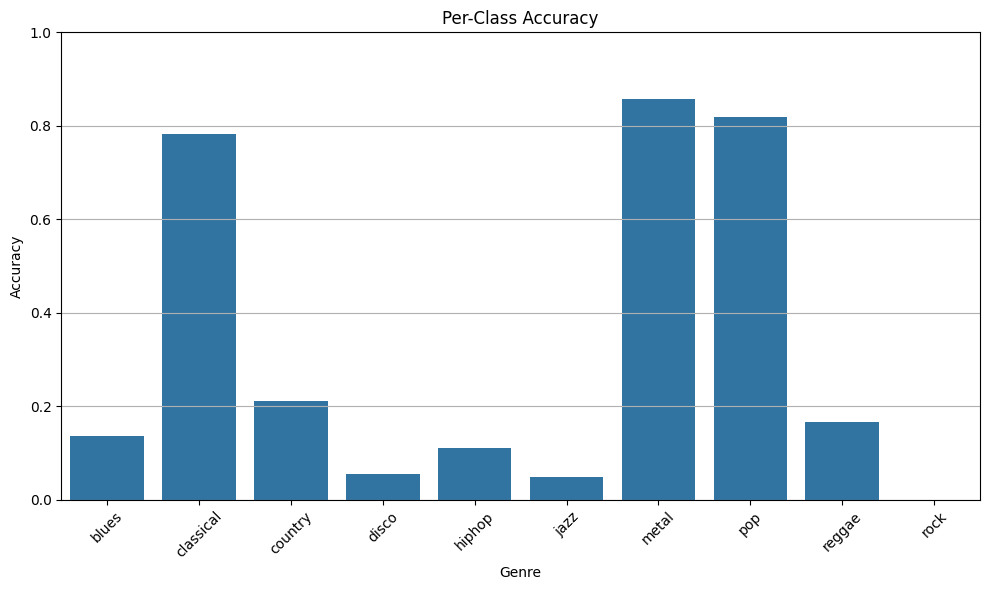

In [ ]:
# Per-class accuracy
per_class_acc = cm.diagonal() / cm.sum(axis=1)

plt.figure(figsize=(10, 6))
sns.barplot(x=classes, y=per_class_acc)
plt.ylim(0, 1)
plt.ylabel('Accuracy')
plt.xlabel('Genre')
plt.title('Per-Class Accuracy')
plt.xticks(rotation=45)
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()


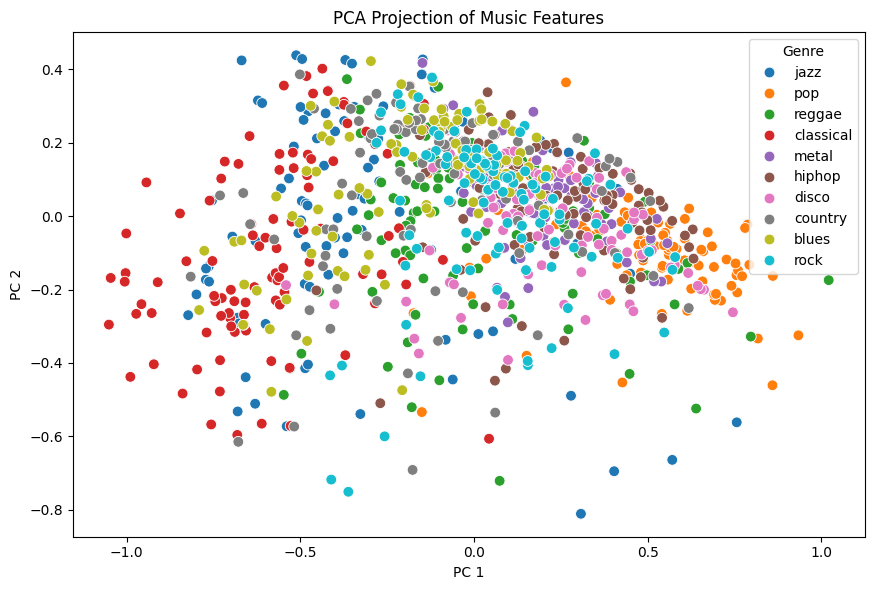

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_norm)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_2d[:, 0], y=X_2d[:, 1], hue=y, palette='tab10', legend='full', s=60)
plt.title('PCA Projection of Music Features')
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.legend(title='Genre', loc='best', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()


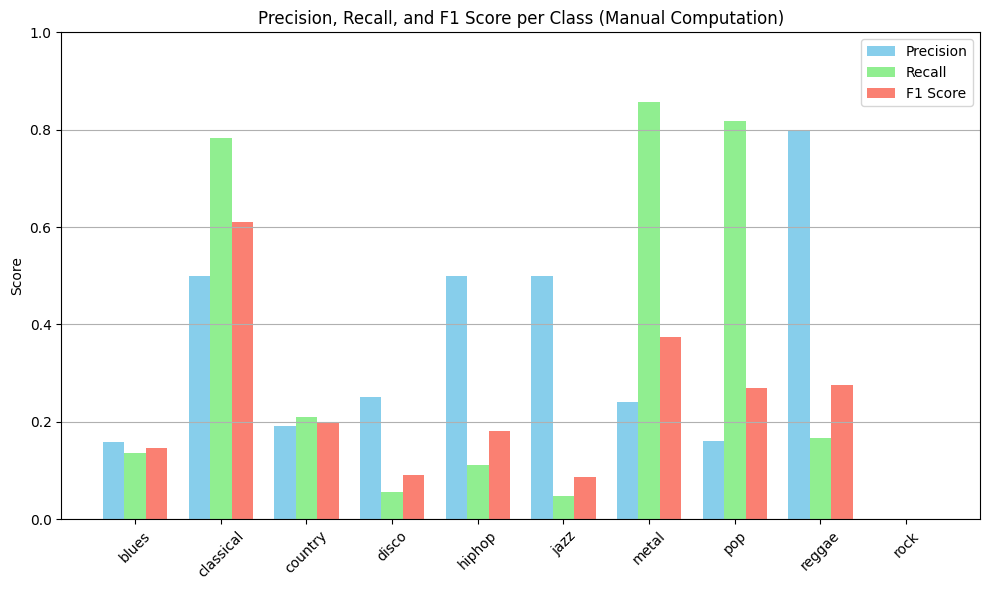

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Build confusion matrix manually
num_classes = len(classes)
cm = np.zeros((num_classes, num_classes), dtype=int)
for true, pred in zip(y_test, y_pred):
    cm[true][pred] += 1

# Compute precision, recall, F1 manually
precision = []
recall = []
f1 = []

for i in range(num_classes):
    TP = cm[i][i]
    FP = np.sum(cm[:, i]) - TP
    FN = np.sum(cm[i, :]) - TP

    prec = TP / (TP + FP + 1e-9)
    rec = TP / (TP + FN + 1e-9)
    f1_score = 2 * prec * rec / (prec + rec + 1e-9)

    precision.append(prec)
    recall.append(rec)
    f1.append(f1_score)

# Bar plot
x = np.arange(len(classes))
width = 0.25

plt.figure(figsize=(10, 6))
plt.bar(x - width, precision, width, label='Precision', color='skyblue')
plt.bar(x, recall, width, label='Recall', color='lightgreen')
plt.bar(x + width, f1, width, label='F1 Score', color='salmon')
plt.xticks(x, classes.astype(str), rotation=45)
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Precision, Recall, and F1 Score per Class (Manual Computation)")
plt.legend()
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()


>

>  random forest

In [ ]:
import numpy as np
import random
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Encode labels
def encode_labels(y):
    label_to_index = {label: idx for idx, label in enumerate(sorted(set(y)))}
    index_to_label = {idx: label for label, idx in label_to_index.items()}
    y_encoded = [label_to_index[label] for label in y]
    return y_encoded, label_to_index, index_to_label

# Train-test split
def train_test_split(X, y, test_ratio=0.2):
    indices = list(range(len(X)))
    random.shuffle(indices)
    split = int(len(X) * (1 - test_ratio))
    train_idx, test_idx = indices[:split], indices[split:]
    return [X[i] for i in train_idx], [y[i] for i in train_idx], [X[i] for i in test_idx], [y[i] for i in test_idx]

# Decision stump (best split on one feature)
def best_split(X, y):
    X_np = np.array(X)
    y_np = np.array(y)
    n_features = X_np.shape[1]
    best_feat, best_thresh, best_gini = None, None, float('inf')

    for feat in range(n_features):
        thresholds = np.unique(X_np[:, feat])
        for thresh in thresholds:
            left = y_np[X_np[:, feat] <= thresh]
            right = y_np[X_np[:, feat] > thresh]
            if len(left) == 0 or len(right) == 0:
                continue
            gini = (len(left)/len(y_np)) * (1 - sum((np.sum(left==c)/len(left))**2 for c in set(left))) + \
                   (len(right)/len(y_np)) * (1 - sum((np.sum(right==c)/len(right))**2 for c in set(right)))
            if gini < best_gini:
                best_gini = gini
                best_feat = feat
                best_thresh = thresh
    return best_feat, best_thresh

# Train a decision stump
def train_stump(X, y):
    feat, thresh = best_split(X, y)
    if feat is None:
        return None
    stump = {'feature': feat, 'threshold': thresh, 'left': None, 'right': None}
    left_labels = [y[i] for i in range(len(X)) if X[i][feat] <= thresh]
    right_labels = [y[i] for i in range(len(X)) if X[i][feat] > thresh]
    stump['left'] = Counter(left_labels).most_common(1)[0][0]
    stump['right'] = Counter(right_labels).most_common(1)[0][0]
    return stump

# Predict with a stump
def predict_stump(stump, x):
    if x[stump['feature']] <= stump['threshold']:
        return stump['left']
    else:
        return stump['right']

# Build a Random Forest
def build_forest(X, y, n_trees=20):
    forest = []
    feature_counts = defaultdict(int)
    for _ in range(n_trees):
        indices = np.random.choice(len(X), size=len(X), replace=True)
        X_sample = [X[i] for i in indices]
        y_sample = [y[i] for i in indices]
        stump = train_stump(X_sample, y_sample)
        if stump:
            forest.append(stump)
            feature_counts[stump['feature']] += 1
    return forest, feature_counts

# Predict with majority voting
def predict_forest(forest, x):
    preds = [predict_stump(tree, x) for tree in forest]
    return Counter(preds).most_common(1)[0][0]

# Evaluate accuracy
def evaluate_forest(forest, X_test, y_test):
    correct = 0
    predictions = []
    for i, x in enumerate(X_test):
        pred = predict_forest(forest, x)
        predictions.append(pred)
        if pred == y_test[i]:
            correct += 1
    accuracy = correct / len(y_test)
    return accuracy, predictions

In [ ]:
# ---------- Run the Random Forest ----------
# Normalize and encode
X_norm = normalize_features(X)
y_encoded, label_to_index, index_to_label = encode_labels(y)

# Split data
X_train, y_train, X_test, y_test = train_test_split(X_norm, y_encoded, test_ratio=0.2)

# Train forest
forest, feature_counts = build_forest(X_train, y_train, n_trees=30)

# Evaluate
accuracy, y_pred = evaluate_forest(forest, X_test, y_test)
print(f"Random Forest Accuracy: {accuracy * 100:.2f}%")

Random Forest Accuracy: 22.00%


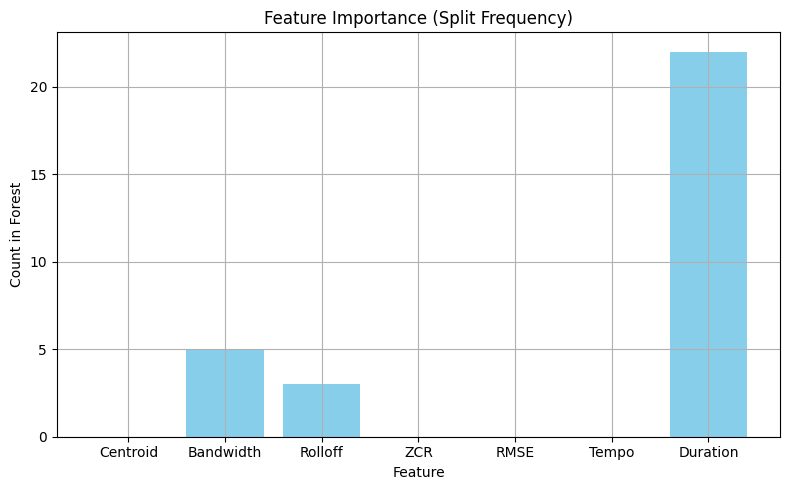

In [ ]:
# ---------- PLOTS ----------
# Plot Feature Importance
plt.figure(figsize=(8, 5))
features = ['Centroid', 'Bandwidth', 'Rolloff', 'ZCR', 'RMSE', 'Tempo', 'Duration']
importances = [feature_counts.get(i, 0) for i in range(len(features))]
plt.bar(features, importances, color='skyblue')
plt.title('Feature Importance (Split Frequency)')
plt.xlabel('Feature')
plt.ylabel('Count in Forest')
plt.grid(True)
plt.tight_layout()
plt.show()

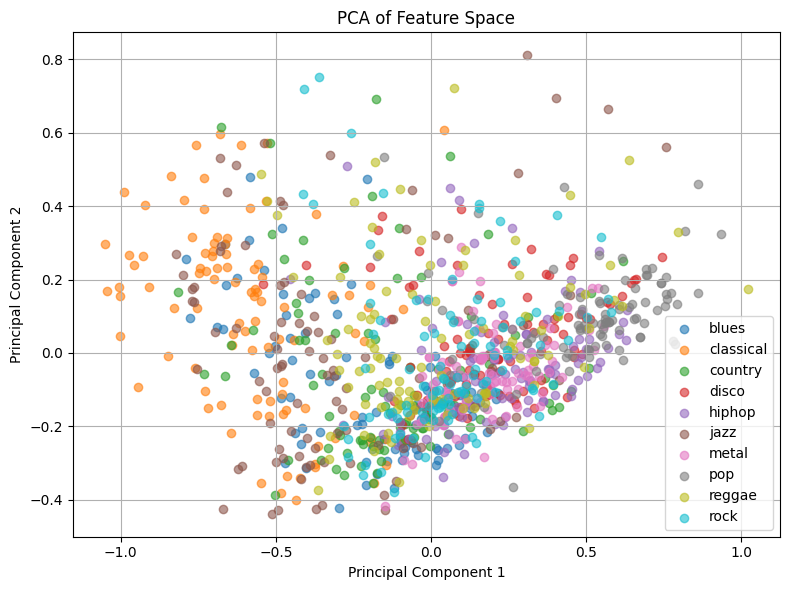

In [ ]:
def plot_pca(X, y, index_to_label):
    X_np = np.array(X)
    y_np = np.array(y)

    # Center the data
    X_centered = X_np - X_np.mean(axis=0)

    # Compute covariance and eigenvalues/vectors
    cov = np.cov(X_centered.T)
    eigvals, eigvecs = np.linalg.eig(cov)

    # Sort by top 2 eigenvectors
    sorted_indices = np.argsort(eigvals)[::-1]
    top2 = eigvecs[:, sorted_indices[:2]]

    X_reduced = X_centered @ top2

    # Plot
    plt.figure(figsize=(8,6))
    unique_labels = sorted(set(y_np))
    for label in unique_labels:
        idx = y_np == label
        plt.scatter(X_reduced[idx, 0], X_reduced[idx, 1], label=index_to_label[label], alpha=0.6)
    plt.title("PCA of Feature Space")
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_pca(X_norm, y_encoded, index_to_label)


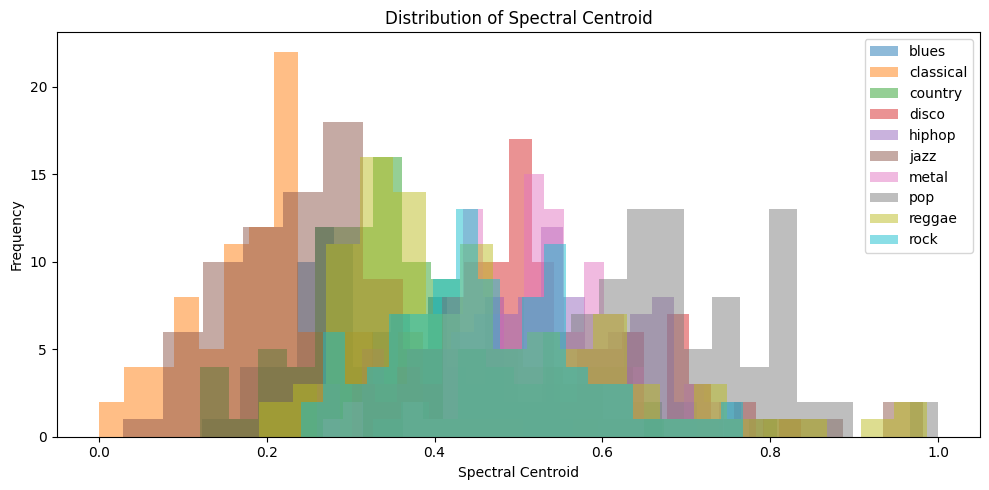

In [ ]:
def plot_feature_distribution(X, y, feature_index, feature_name, index_to_label):
    plt.figure(figsize=(10, 5))
    for label in sorted(set(y)):
        values = [X[i][feature_index] for i in range(len(X)) if y[i] == label]
        plt.hist(values, bins=20, alpha=0.5, label=index_to_label[label])
    plt.title(f"Distribution of {feature_name}")
    plt.xlabel(feature_name)
    plt.ylabel("Frequency")
    plt.legend()
    plt.tight_layout()
    plt.show()

# Example: Spectral Centroid (index 0)
plot_feature_distribution(X_norm, y_encoded, 0, 'Spectral Centroid', index_to_label)


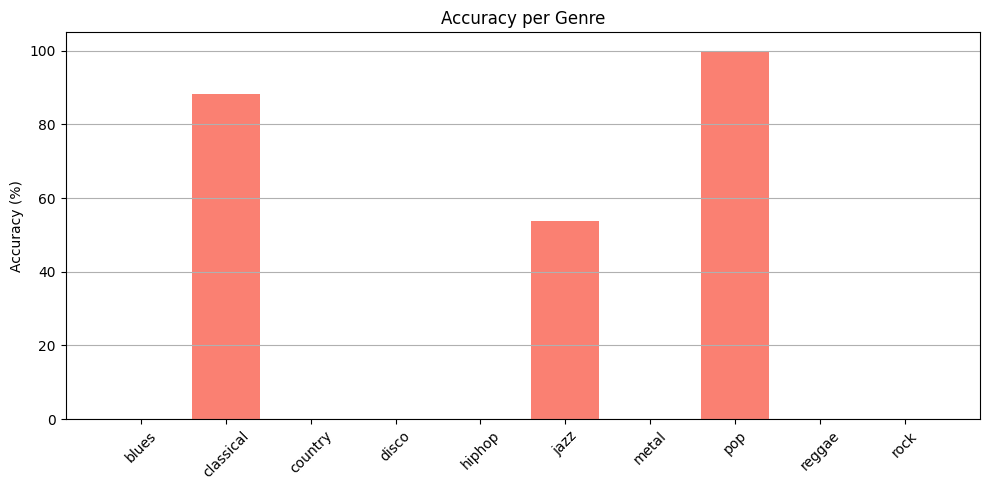

In [ ]:
def plot_accuracy_per_genre(y_true, y_pred, index_to_label):
    genre_acc = {}
    genres = sorted(set(y_true))
    for genre in genres:
        genre_true = [y for i, y in enumerate(y_true) if y == genre]
        genre_pred = [y_pred[i] for i in range(len(y_true)) if y_true[i] == genre]
        acc = np.mean([1 if genre_true[i] == genre_pred[i] else 0 for i in range(len(genre_true))])
        genre_acc[index_to_label[genre]] = acc * 100

    plt.figure(figsize=(10, 5))
    plt.bar(genre_acc.keys(), genre_acc.values(), color='salmon')
    plt.ylabel('Accuracy (%)')
    plt.title('Accuracy per Genre')
    plt.xticks(rotation=45)
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()

plot_accuracy_per_genre(y_test, y_pred, index_to_label)
